<a href="https://colab.research.google.com/github/epjf99-rgb/Entregas/blob/main/2025Jun18CatDogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ingestar datos

In [ ]:
! curl -L -o cat-and-dog.zip  https://www.kaggle.com/api/v1/datasets/download/tongpython/cat-and-dog

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  217M  100  217M    0     0  18.8M      0  0:00:11  0:00:11 --:--:-- 22.4M


In [ ]:
# prompt: descomprimir el archivo cat-and-dog.zip , mode silencioso y reemplazar si ya fue descompreso

! unzip -o -q cat-and-dog.zip

In [ ]:
!ls training_set/training_set/cats/*.jpg  | wc -l

4000


In [ ]:
!ls  training_set/training_set/dogs/*.jpg  | wc -l

4005


In [ ]:
!ls  test_set/test_set/cats/*.jpg  | wc -l

1011


In [ ]:
!ls -R test_set/test_set/dogs/*.jpg  | wc -l

1012


In [ ]:
!# rm -rf test_set/ training_set/

# Feature Engineering

## Cargar imagenes como tensores

In [ ]:
# prompt: utilizando Keras,  usar carpetas  training_set/training_set cargar los archivos de imagenes que son dos categorias, dogs y cats

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)
training_set = train_datagen.flow_from_directory('training_set/training_set',
                                                 target_size = (64, 64),
                                                 batch_size = 32,
                                                 class_mode = 'binary')

test_datagen = ImageDataGenerator(rescale = 1./255)
test_set = test_datagen.flow_from_directory('test_set/test_set',
                                            target_size = (64, 64),
                                            batch_size = 32,
                                            class_mode = 'binary')

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


# Entrenar con una CNN

In [ ]:
# prompt: utilizando Keras entrena una red neuronal convulocional

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

cnn = Sequential()
cnn.add(Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=[64, 64, 3]))
cnn.add(MaxPooling2D(pool_size=2, strides=2))
cnn.add(Conv2D(filters=32, kernel_size=3, activation='relu'))
cnn.add(MaxPooling2D(pool_size=2, strides=2))
cnn.add(Flatten())
cnn.add(Dense(units=128, activation='relu'))
cnn.add(Dense(units=1, activation='sigmoid'))

cnn.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

history=cnn.fit(x = training_set, validation_data = test_set, epochs = 25)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 30s 104ms/step - accuracy: 0.5328 - loss: 0.6895 - val_accuracy: 0.6530 - val_loss: 0.6148
Epoch 2/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 27s 109ms/step - accuracy: 0.6766 - loss: 0.5990 - val_accuracy: 0.7004 - val_loss: 0.5856
Epoch 3/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.7147 - loss: 0.5469 - val_accuracy: 0.7168 - val_loss: 0.5615
Epoch 4/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.7530 - loss: 0.5085 - val_accuracy: 0.7444 - val_loss: 0.5278
Epoch 5/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.7588 - loss: 0.5029 - val_accuracy: 0.7667 - val_loss: 0.4852
Epoch 6/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.7602 - loss: 0.4909 - val_accuracy: 0.7306 - val_loss: 0.5498
Epoch 7/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 90ms/step - accuracy: 0.7893 - loss: 0.4548 - val_accuracy: 0.7761 - val_loss: 0.4681
Epoch 8/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.7992 - loss: 0.4351 

In [ ]:
# prompt: funcion que grafique accuracy y val_accuracy asi como loss y val_loss usando matplotlib y como parametro la historia regresado por fit de Keras

import matplotlib.pyplot as plt

def plot_training_history(history):
  """
  Plots the accuracy and loss of a Keras model training history.

  Args:
    history: The History object returned by a Keras model's fit method.
  """
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs_range = range(len(acc))

  plt.figure(figsize=(12, 4))
  plt.subplot(1, 2, 1)
  plt.plot(epochs_range, acc, label='Training Accuracy')
  plt.plot(epochs_range, val_acc, label='Validation Accuracy')
  plt.legend(loc='lower right')
  plt.title('Training and Validation Accuracy')

  plt.subplot(1, 2, 2)
  plt.plot(epochs_range, loss, label='Training Loss')
  plt.plot(epochs_range, val_loss, label='Validation Loss')
  plt.legend(loc='upper right')
  plt.title('Training and Validation Loss')
  plt.show()



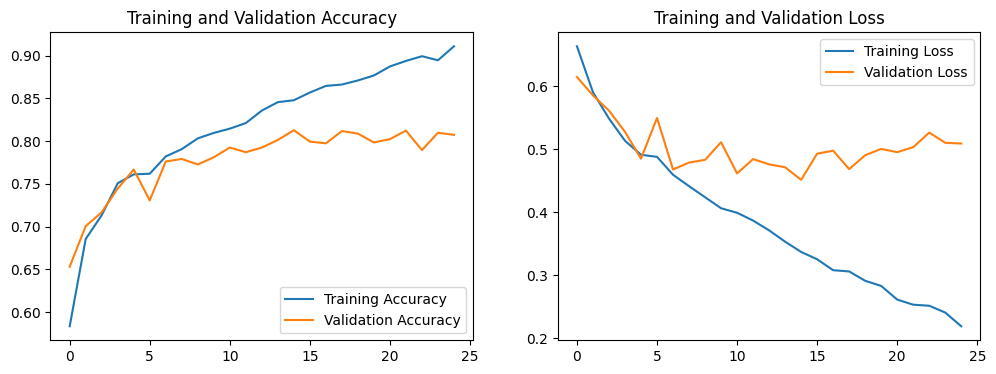

In [ ]:
plot_training_history(history)


# Entrenar con un modelo de TinyVGG

In [ ]:
model_tiny = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(filters=10,
                         kernel_size=3, # can also be (3, 3)
                         activation="relu",
                         input_shape=(64, 64, 3)), # first layer specifies input shape (height, width, colour channels)
  tf.keras.layers.Conv2D(10, 3, activation="relu"),
  tf.keras.layers.MaxPool2D(pool_size=2, # pool_size can also be (2, 2)
                            padding="valid"), # padding can also be 'same'
  tf.keras.layers.Conv2D(10, 3, activation="relu"),
  tf.keras.layers.Conv2D(10, 3, activation="relu"), # activation='relu' == tf.keras.layers.Activations(tf.nn.relu)
  tf.keras.layers.MaxPool2D(2),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(1, activation="sigmoid") # binary activation output
])


In [ ]:
model_tiny.compile(loss="binary_crossentropy",
                   optimizer=tf.keras.optimizers.Adam(), # reduce the learning rate (default lr is often too high for us)
                   metrics=["accuracy"])

In [ ]:
histoy1=model_tiny.fit(x = training_set, validation_data = test_set, epochs = 5)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 29s 102ms/step - accuracy: 0.5214 - loss: 0.6904 - val_accuracy: 0.5492 - val_loss: 0.6727
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.5994 - loss: 0.6557 - val_accuracy: 0.6584 - val_loss: 0.6144
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.6638 - loss: 0.6139 - val_accuracy: 0.6307 - val_loss: 0.6306
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.6842 - loss: 0.5791 - val_accuracy: 0.7098 - val_loss: 0.5653
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.7077 - loss: 0.5552 - val_accuracy: 0.7346 - val_loss: 0.5398


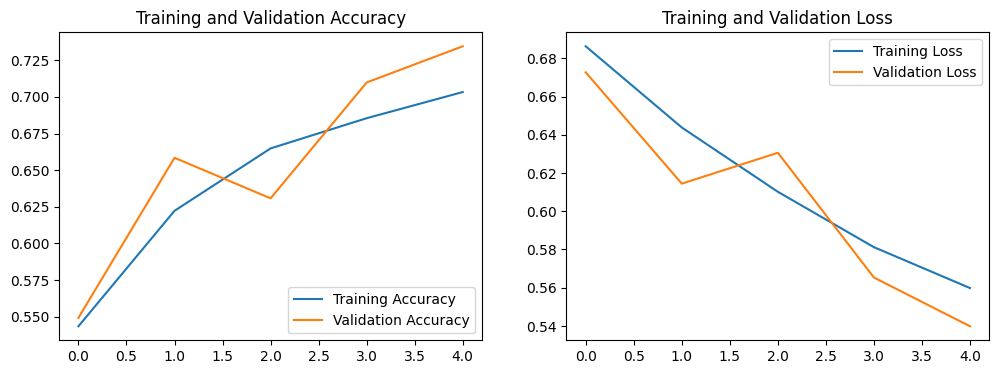

In [ ]:
plot_training_history(histoy1)


# Entrenar TinyVGG modificado

In [ ]:
model_tiny2 = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(filters=10,
                         kernel_size=3, # can also be (3, 3)
                         activation="relu",
                         input_shape=(64, 64, 3)), # first layer specifies input shape (height, width, colour channels)
  tf.keras.layers.Conv2D(10, 3, activation="relu"),
  tf.keras.layers.MaxPool2D(pool_size=2, # pool_size can also be (2, 2)
                            padding="valid"), # padding can also be 'same'
  tf.keras.layers.Conv2D(10, 3, activation="relu"),
  tf.keras.layers.Conv2D(10, 3, activation="relu"), # activation='relu' == tf.keras.layers.Activations(tf.nn.relu)
  tf.keras.layers.MaxPool2D(2),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(1, activation="sigmoid") # binary activation output
])

In [ ]:
model_tiny2.compile(loss="binary_crossentropy",
                   optimizer=tf.keras.optimizers.Adam(), # reduce the learning rate (default lr is often too high for us)
                   metrics=["accuracy"])

In [ ]:
history2=model_tiny2.fit(x = training_set, validation_data = test_set, epochs = 5)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 30s 104ms/step - accuracy: 0.5181 - loss: 0.6927 - val_accuracy: 0.6303 - val_loss: 0.6472
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.6384 - loss: 0.6402 - val_accuracy: 0.6619 - val_loss: 0.6123
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 93ms/step - accuracy: 0.6813 - loss: 0.6016 - val_accuracy: 0.7029 - val_loss: 0.5733
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.7023 - loss: 0.5695 - val_accuracy: 0.7286 - val_loss: 0.5398
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.7246 - loss: 0.5426 - val_accuracy: 0.7252 - val_loss: 0.5569


In [ ]:
plot_training_history(histoy2)

NameError: name 'histoy2' is not defined

# Image Data Augmentation

In [ ]:
# prompt: aplicar aumentacion de datos para el dataset de train
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# # Image Data Augmentation
train_datagen_augmented = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True,
                                   rotation_range=20, # Rotate images randomly by up to 20 degrees
                                   width_shift_range=0.1, # Shift images horizontally by up to 10% of the width
                                   height_shift_range=0.1 # Shift images vertically by up to 10% of the height
                                             )

training_set_augmented = train_datagen_augmented.flow_from_directory('training_set/training_set',
                                                 target_size = (128, 128),
                                                 batch_size = 32,
                                                 class_mode = 'binary')

# You would then use training_set_augmented when fitting your model
# For example:
# cnn.fit(x = training_set_augmented, validation_data = test_set, epochs = 25)
# model_tiny.fit(x = training_set_augmented, validation_data = test_set, epochs = 5)
# model_tiny2.fit(x = training_set_augmented, validation_data = test_set, epochs = 5)

In [ ]:
test_datagen = ImageDataGenerator(rescale = 1./255)
test_set = test_datagen.flow_from_directory('test_set/test_set',
                                            target_size = (128, 128),
                                            batch_size = 32,
                                            class_mode = 'binary')

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [ ]:
model_tiny2 = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(filters=10,
                         kernel_size=3, # can also be (3, 3)
                         activation="relu",
                         input_shape=(128, 128, 3)), # first layer specifies input shape (height, width, colour channels)
  tf.keras.layers.Conv2D(10, 3, activation="relu"),
  tf.keras.layers.MaxPool2D(pool_size=2, # pool_size can also be (2, 2)
                            padding="valid"), # padding can also be 'same'
  tf.keras.layers.Conv2D(10, 3, activation="relu"),
  tf.keras.layers.Conv2D(10, 3, activation="relu"), # activation='relu' == tf.keras.layers.Activations(tf.nn.relu)
  tf.keras.layers.MaxPool2D(2),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(1, activation="sigmoid") # binary activation output
])

In [ ]:
model_tiny2.compile(loss="binary_crossentropy",
                   optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), # reduce the learning rate (default lr is often too high for us)
                   metrics=["accuracy"])

In [ ]:
history=model_tiny2.fit(x = training_set_augmented, validation_data = test_set, epochs = 50)

In [ ]:
plot_training_history(history)

In [ ]:
# prompt: evalua la precision

# Evaluate the accuracy and loss of the last trained model on the test set
loss, accuracy = model_tiny2.evaluate(test_set)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Variar la tasa de aprendizaje

In [ ]:
from tensorflow.keras.callbacks import LearningRateScheduler
lr_scheduler = LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20)) # traverse a set of learning rate values starting from 1e-4, increasing by 10**(epoch/20) every epoch


In [ ]:
model_tiny2_5 = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(filters=32,
                         kernel_size=3, # can also be (3, 3)
                         activation="relu",
                         input_shape=(128, 128, 3)), # first layer specifies input shape (height, width, colour channels)
  tf.keras.layers.Conv2D(10, 3, activation="relu"),
  tf.keras.layers.MaxPool2D(pool_size=2, # pool_size can also be (2, 2)
                            padding="valid"), # padding can also be 'same'
  tf.keras.layers.Conv2D(10, 3, activation="relu"),
  tf.keras.layers.Conv2D(10, 3, activation="relu"), # activation='relu' == tf.keras.layers.Activations(tf.nn.relu)
  tf.keras.layers.MaxPool2D(2),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(64, activation="relu"),
  tf.keras.layers.Dense(32, activation="relu"),
  tf.keras.layers.Dense(1, activation="sigmoid") # binary activation output
])

In [ ]:
model_tiny2_5.compile(loss="binary_crossentropy",
                   optimizer=tf.keras.optimizers.Adam(),
                   metrics=["accuracy"])

In [ ]:
history4=model_tiny2_5.fit(x = training_set_augmented, validation_data = test_set, epochs = 50,callbacks=[lr_scheduler])

### mejor learning rate es 0.0022

In [ ]:
plot_training_history(history4)

In [ ]:
# prompt: graficar learning_rate vs accuracy, usando los datos de history

import matplotlib.pyplot as plt
# Graficar Learning Rate vs Accuracy
lrs = 1e-4 * (10**(tf.range(50)/20))
plt.figure(figsize=(12, 6))
plt.semilogx(lrs, history4.history['accuracy'])
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Learning Rate vs. Accuracy")
plt.show()

In [ ]:
# Modelo con learning rate 0.0022

In [ ]:
model_tiny2_6 = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(filters=32,
                         kernel_size=3, # can also be (3, 3)
                         activation="relu",
                         input_shape=(128, 128, 3)), # first layer specifies input shape (height, width, colour channels)
  tf.keras.layers.Conv2D(10, 3, activation="relu"),
  tf.keras.layers.MaxPool2D(pool_size=2, # pool_size can also be (2, 2)
                            padding="valid"), # padding can also be 'same'
  tf.keras.layers.Conv2D(10, 3, activation="relu"),
  tf.keras.layers.Conv2D(10, 3, activation="relu"), # activation='relu' == tf.keras.layers.Activations(tf.nn.relu)
  tf.keras.layers.MaxPool2D(2),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(64, activation="relu"),
  tf.keras.layers.Dense(32, activation="relu"),
  tf.keras.layers.Dense(1, activation="sigmoid") # binary activation output
])

In [ ]:
model_tiny2_6.compile(loss="binary_crossentropy",
                   optimizer=tf.keras.optimizers.Adam(learning_rate=0.0022),
                   metrics=["accuracy"])

In [ ]:
history5=model_tiny2_6.fit(x = training_set_augmented, validation_data = test_set, epochs = 10)

In [ ]:
plot_training_history(history5)

# Transfer learning con un modelo pre entrenado

---



In [ ]:
# Transfer learning with a pre-trained model (VGG19)
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model # Import Model
from tensorflow.keras.layers import Dense, Flatten # Import Dense and Flatten
import matplotlib.pyplot as plt

# Define the plotting function
def plot_training_history(history):
  """
  Plots the accuracy and loss of a Keras model training history.

  Args:
    history: The History object returned by a Keras model's fit method.
  """
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs_range = range(len(acc))

  plt.figure(figsize=(12, 4))
  plt.subplot(1, 2, 1)
  plt.plot(epochs_range, acc, label='Training Accuracy')
  plt.plot(epochs_range, val_acc, label='Validation Accuracy')
  plt.legend(loc='lower right')
  plt.title('Training and Validation Accuracy')

  plt.subplot(1, 2, 2)
  plt.plot(epochs_range, loss, label='Training Loss')
  plt.plot(epochs_range, val_loss, label='Validation Loss')
  plt.legend(loc='upper right')
  plt.title('Training and Validation Loss')
  plt.show()


# Load the VGG19 model pre-trained on ImageNet
# include_top=False removes the final classification layer, allowing us to add our own
base_model_vgg19 = VGG19(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
# Freeze the layers of the base model
for layer in base_model_vgg19.layers:
    layer.trainable = False
# Add custom layers for binary classification (cats vs dogs)
x = Flatten()(base_model_vgg19.output)
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x) # Output layer for binary classification
# Create the new model
model_vgg19 = Model(inputs=base_model_vgg19.input, outputs=predictions)
# Compile the model
model_vgg19.compile(loss="binary_crossentropy",
                    optimizer=tf.keras.optimizers.Adam(),
                    metrics=["accuracy"])
# Train the model
history_vgg19 = model_vgg19.fit(x = training_set_augmented,
                                validation_data = test_set,
                                epochs = 5) # Reduced epochs for quicker example
plot_training_history(history_vgg19)

NameError: name 'training_set_augmented' is not defined

In [ ]:
model_vgg16.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,861,189 (68.14 MB)

 Trainable params: 1,048,833 (4.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 2,097,668 (8.00 MB)

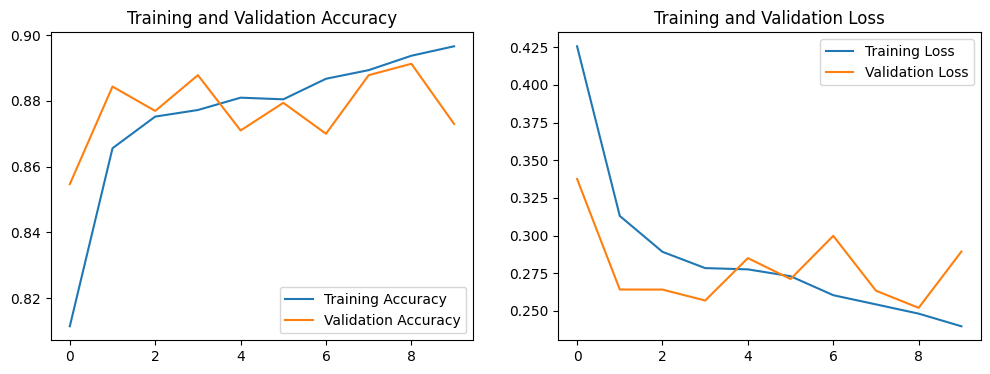

64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.8806 - loss: 0.2704
VGG16 Test Loss: 0.2893
VGG16 Test Accuracy: 0.8730


In [ ]:
# Plot the training history
plot_training_history(history_vgg16)

# Evaluate the model on the test set
loss_vgg16, accuracy_vgg16 = model_vgg16.evaluate(test_set)

print(f"VGG16 Test Loss: {loss_vgg16:.4f}")
print(f"VGG16 Test Accuracy: {accuracy_vgg16:.4f}")

In [ ]:
# Fine tuning con modelo pre entrenado

Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 67s 225ms/step - accuracy: 0.7691 - loss: 0.4493 - val_accuracy: 0.9145 - val_loss: 0.2011
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 52s 207ms/step - accuracy: 0.9233 - loss: 0.1847 - val_accuracy: 0.9348 - val_loss: 0.1821
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 52s 206ms/step - accuracy: 0.9441 - loss: 0.1415 - val_accuracy: 0.9496 - val_loss: 0.1240
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 52s 207ms/step - accuracy: 0.9509 - loss: 0.1218 - val_accuracy: 0.9575 - val_loss: 0.1071
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 82s 207ms/step - accuracy: 0.9666 - loss: 0.0884 - val_accuracy: 0.9525 - val_loss: 0.1218
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 53s 213ms/step - accuracy: 0.9659 - loss: 0.0875 - val_accuracy: 0.9614 - val_loss: 0.1038
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 52s 206ms/step - accuracy: 0.9741 - loss: 0.0712 - val_accuracy: 0.9565 - val_loss: 0.1129
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 52s 207ms/step - accuracy: 0.9736 - loss: 0

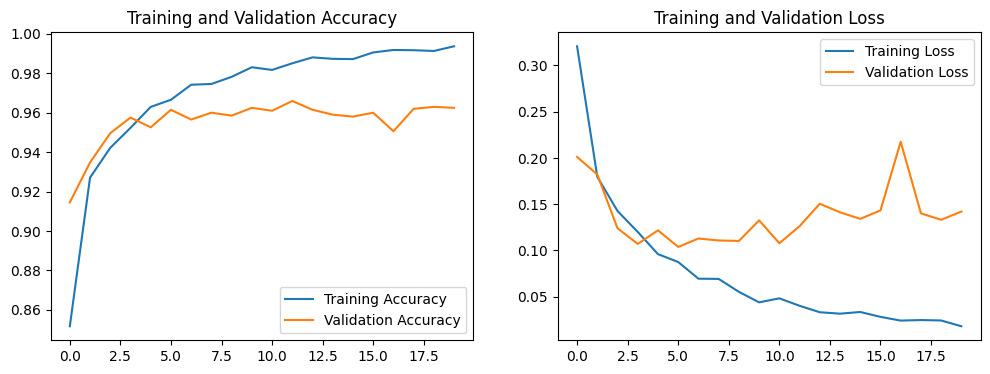

64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9591 - loss: 0.1693
Fine-tuned VGG16 Test Loss: 0.1421
Fine-tuned VGG16 Test Accuracy: 0.9624


In [ ]:
# prompt: codigo para hacer finetuning tensorflow.keras.applications.VGG16 haciendo freeze de todas las capas menos las 10 ultimas. Carga de neuvo VGG16

# Load the VGG16 model pre-trained on ImageNet again, without the top layer
base_model_finetune = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Unfreeze the last 10 layers
for layer in base_model_finetune.layers[:-10]:
  layer.trainable = False
for layer in base_model_finetune.layers[-10:]:
  layer.trainable = True

# Add custom layers for binary classification (cats vs dogs)
x = Flatten()(base_model_finetune.output)
x = Dense(128, activation='relu')(x)
predictions_finetune = Dense(1, activation='sigmoid')(x) # Output layer for binary classification

# Create the new model for fine-tuning
model_finetune = Model(inputs=base_model_finetune.input, outputs=predictions_finetune)

# Compile the model with a lower learning rate for fine-tuning
model_finetune.compile(loss="binary_crossentropy",
                      optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Use a smaller learning rate
                      metrics=["accuracy"])

# Train the model
# It's often beneficial to train for more epochs during fine-tuning
history_finetune = model_finetune.fit(x = training_set_augmented,
                                     validation_data = test_set,
                                     epochs = 20) # Increase epochs for fine-tuning

# Plot the training history
plot_training_history(history_finetune)

# Evaluate the model on the test set
loss_finetune, accuracy_finetune = model_finetune.evaluate(test_set)

print(f"Fine-tuned VGG16 Test Loss: {loss_finetune:.4f}")
print(f"Fine-tuned VGG16 Test Accuracy: {accuracy_finetune:.4f}")


In [ ]:
model_finetune.save('catdogs_model_finetune.keras')